                 RX0          RX1           RX2           RX3
0      -230.0-144.0j -79.0-145.0j -159.0-239.0j -135.0-295.0j
1      -218.0-171.0j -68.0-144.0j -146.0-253.0j -133.0-322.0j
2      -196.0-184.0j -55.0-141.0j -119.0-271.0j  -88.0-304.0j
3      -203.0-186.0j -35.0-135.0j -103.0-268.0j  -74.0-307.0j
4      -180.0-184.0j  -6.0-153.0j -111.0-288.0j  -42.0-303.0j
...              ...          ...           ...           ...
262139  -38.0+243.0j   2.0+145.0j  -77.0+277.0j  -98.0+ 29.0j
262140  -37.0+267.0j -13.0+146.0j  -72.0+268.0j -121.0+ 16.0j
262141  -33.0+257.0j -29.0+127.0j -114.0+272.0j -128.0-  7.0j
262142  -58.0+238.0j -24.0+127.0j  -97.0+289.0j -147.0+  9.0j
262143  -75.0+257.0j -25.0+119.0j -100.0+288.0j -136.0-  1.0j

[262144 rows x 4 columns]


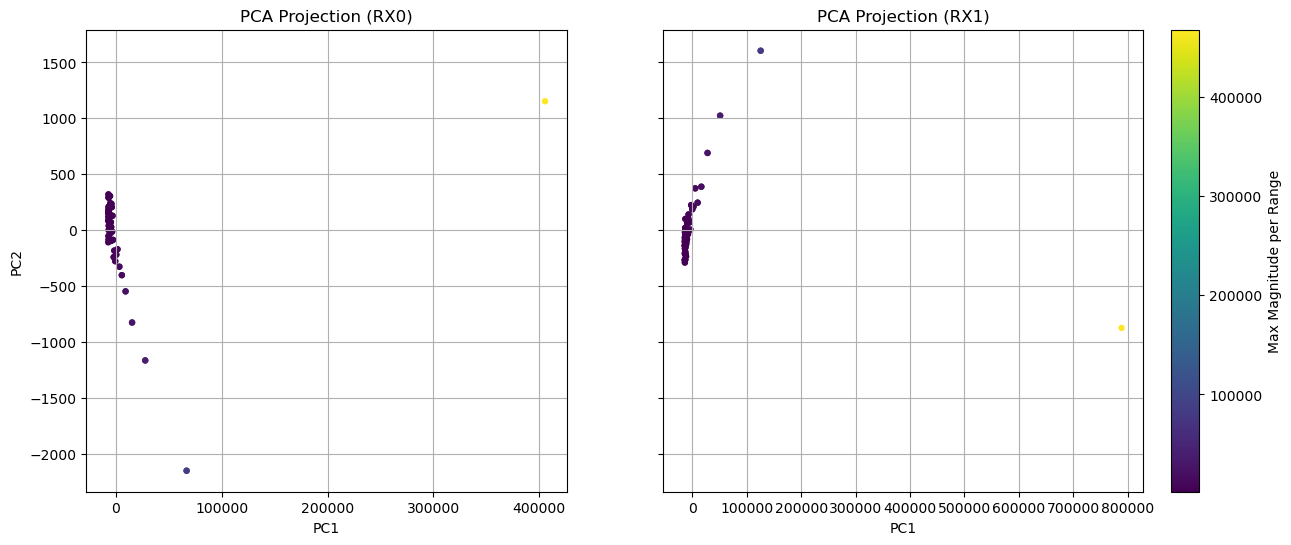

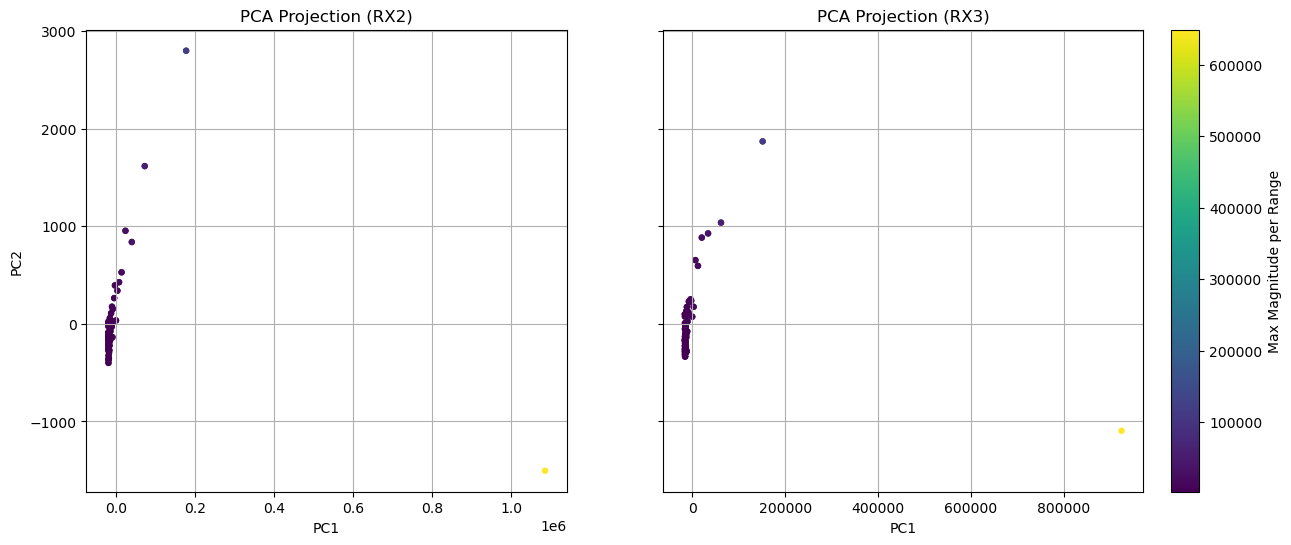

In [18]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def convert_to_data_frame(matlabFilePath, variableName):
    matData = scipy.io.loadmat(matlabFilePath)
    xdata = matData[variableName]

    df = pd.DataFrame(xdata)
    df = df.transpose()
    df.columns = ['RX0', 'RX1', 'RX2', 'RX3']
    print(df)
    return df

#Parameters
numADCSamples = 256
numChirps = 1024
Nfft_range = 256
Nfft_doppler = 128
Fs = 10e6          # sampling rate (Hz)
c = 3e8            # speed of light (m/s)
slope = 29.982e12  # chirp slope (Hz/s)
fc = 77e9          # carrier frequency (Hz)
chirpPeriod = 40e-3  # chirp duration (s)
chirpRate = 1 / chirpPeriod

def doppler_range_pca_two(df, rx_list):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    for i, rx in enumerate(rx_list):
        # Reshape RX channel
        rx_series = df[rx]
        rx_matrix = rx_series.values.reshape(numChirps, numADCSamples)
        df_rx = pd.DataFrame(rx_matrix)

        # Range FFT
        window_range = np.hamming(numADCSamples)
        df_rx = df_rx.mul(window_range, axis=1)
        df_rx = df_rx.sub(df_rx.mean(axis=1), axis=0)

        rangeFFT = np.fft.fft(df_rx.values, n=Nfft_range, axis=1)
        rangeFFT = np.abs(rangeFFT[:, :Nfft_range//2])

        # Doppler FFT
        window_doppler = np.hamming(numChirps)
        rangeFFT_win = rangeFFT * window_doppler[:, np.newaxis]
        dopplerFFT = np.fft.fftshift(
            np.fft.fft(rangeFFT_win, n=Nfft_doppler, axis=0),
            axes=0
        )
        dopplerFFT = np.abs(dopplerFFT)

        # PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(dopplerFFT)

        # Scatter plot
        sc = axs[i].scatter(X_pca[:, 0], X_pca[:, 1],
                            c=np.max(dopplerFFT, axis=1), cmap='viridis', s=13)
        axs[i].set_title(f"PCA Projection ({rx})")
        axs[i].set_xlabel("PC1")
        if i == 0:
            axs[i].set_ylabel("PC2")
        axs[i].grid(True)

    # Shared colorbar outside the plots
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.9, 0.11, 0.02, 0.77])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Max Magnitude per Range")

    plt.show()


adcData = convert_to_data_frame(r'C:\Users\kavin\20250110\_5\adc_data.mat', 'ans')
doppler_range_pca_two(adcData, ['RX0', 'RX1'])
doppler_range_pca_two(adcData, ['RX2', 'RX3'])
